<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/MTA_Shapley/MTAShapley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First Touch Attribution: defaultdict(<class 'float'>, {'Display': 275.0, 'Referral': 290.0, 'Social Media': 307.0, 'Search': 291.0, 'Email': 316.0, 'Direct': 308.0})
Last Touch Attribution: defaultdict(<class 'float'>, {'Search': 285.0, 'Direct': 318.0, 'Email': 303.0, 'Social Media': 305.0, 'Display': 252.0, 'Referral': 324.0})
Shapley Value Attribution: defaultdict(<class 'float'>, {'Display': 2044.4114583333337, 'Referral': 2587.473958333333, 'Search': 2136.942708333333, 'Email': 1908.8645833333335, 'Direct': 2221.864583333334, 'Social Media': 2275.380208333334})


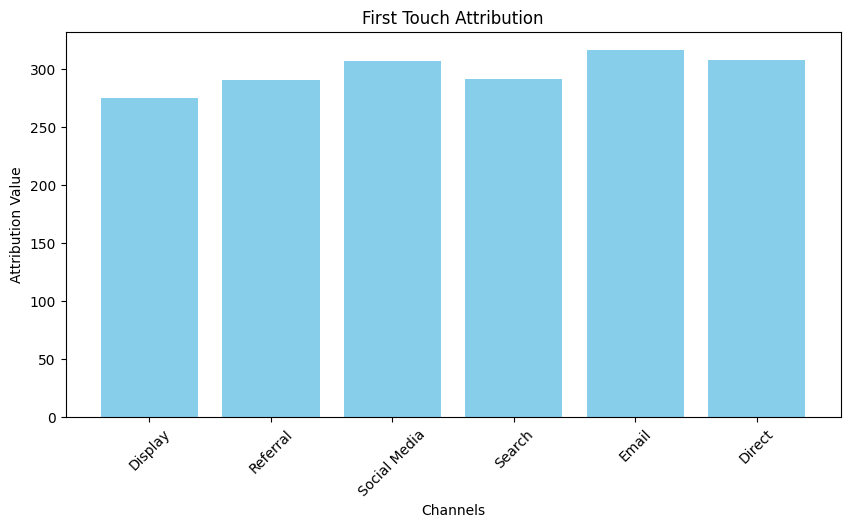

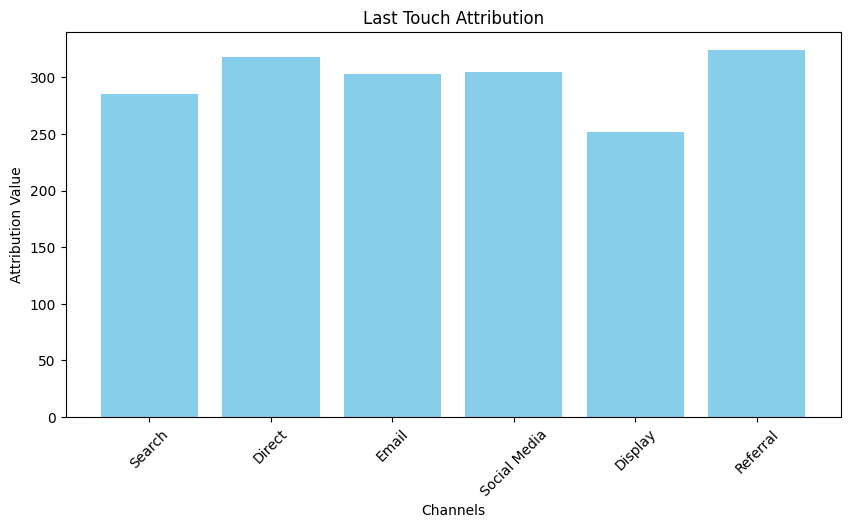

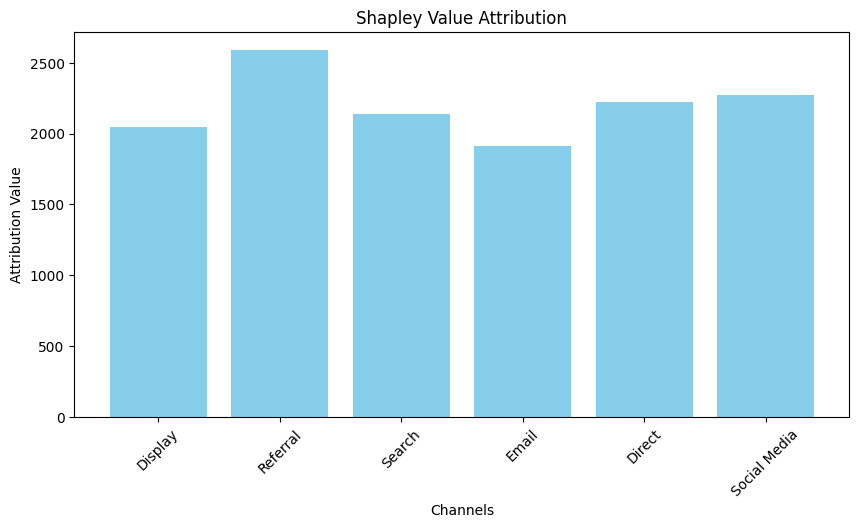

In [ ]:
import pandas as pd
from collections import defaultdict
from itertools import chain, combinations
import numpy as np
import matplotlib.pyplot as plt

def powerset(iterable):
    """Returns the powerset of an iterable."""
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

def shapley_value(conversions, channels):
    """Calculate Shapley values for each marketing channel."""
    channel_values = defaultdict(float)
    num_channels = len(channels)

    for channel in channels:
        for subset in powerset(channels - {channel}):
            subset = set(subset)
            subset_value = conversions.get(frozenset(subset), 0)
            larger_subset = subset | {channel}
            larger_value = conversions.get(frozenset(larger_subset), 0)
            marginal_contribution = larger_value - subset_value
            channel_values[channel] += marginal_contribution / (num_channels * len(list(powerset(subset))))

    return channel_values

def first_touch_attribution(data):
    """Calculate First-Touch Attribution."""
    first_touch = defaultdict(float)
    for journey, converted in data:
        if converted:
            first_touch[journey[0]] += 1
    return first_touch

def last_touch_attribution(data):
    """Calculate Last-Touch Attribution."""
    last_touch = defaultdict(float)
    for journey, converted in data:
        if converted:
            last_touch[journey[-1]] += 1
    return last_touch

# Upload and read CSV file
def load_csv(file_path):
    df = pd.read_csv(file_path)
    df['journey'] = df['journey'].apply(lambda x: eval(x))  # Convert string representation to list
    data = [(tuple(journey), converted) for journey, converted in zip(df['journey'], df['converted'])]
    return data

file_path = "/content/multi_touch_attribution_data.csv"  # Replace with the actual file path
data = load_csv(file_path)

# First Touch Attribution
first_touch_results = first_touch_attribution(data)
print("First Touch Attribution:", first_touch_results)

# Last Touch Attribution
last_touch_results = last_touch_attribution(data)
print("Last Touch Attribution:", last_touch_results)

# Shapley Value Attribution
conversions = defaultdict(int)
for journey, converted in data:
    if converted:
        for subset in powerset(journey):
            conversions[frozenset(subset)] += 1

channels = set(chain(*[journey for journey, _ in data]))
shapley_results = shapley_value(conversions, channels)
print("Shapley Value Attribution:", shapley_results)

# Plot results
def plot_results(results, title):
    plt.figure(figsize=(10, 5))
    plt.bar(results.keys(), results.values(), color='skyblue')
    plt.xlabel("Channels")
    plt.ylabel("Attribution Value")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_results(first_touch_results, "First Touch Attribution")
plot_results(last_touch_results, "Last Touch Attribution")
plot_results(shapley_results, "Shapley Value Attribution")